### Justification or answer for each task/question

###  1.1 ** Download the "placement.csv" 

### 1.1 Start

In [27]:
import warnings
warnings.filterwarnings('ignore')

In [28]:
import pandas as pd
dataset=pd.read_csv("placement.csv")

In [29]:
dataset.head(3)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0


### 1.1 End

### 1.2 1)Replace the NaN values with correct value. And justify why you have
### chosen the same.
### 1.2 Start

In [30]:
dataset.columns

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')

In [31]:
dataset["ssc_p"].dtype

dtype('float64')

In [32]:
dataset["gender"].dtype

dtype('O')

In [33]:
## define a function to identify quantitative(numeric) and qualitative columns
def quanQual(dataset):
    qual=[]
    quan=[]
    for col_name in dataset.columns:
        if(dataset[col_name].dtype == 'O'):
            qual.append(col_name)
            #print("qual")
        else:
            quan.append(col_name)
            #print("quan")
    return(quan,qual)

In [34]:
quan,qual=quanQual(dataset)

In [35]:
quan

['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

In [36]:
qual

['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

In [37]:
dataset.describe().head()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000


In [38]:
dataset.describe(include='all').head(3)

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
count,215.0,215,215.0,215,215.0,215,215,215.0,215,215,215.0,215,215.0,215,148.0
unique,NaN,2,NaN,2,NaN,2,3,NaN,3,2,NaN,2,NaN,2,NaN
top,NaN,M,NaN,Central,NaN,Others,Commerce,NaN,Comm&Mgmt,No,NaN,Mkt&Fin,NaN,Placed,NaN


### Check for null values

In [39]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [40]:
dataset[dataset['salary'].isnull()]

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
3,4,M,56.0,Central,52.0,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
5,6,M,55.0,Others,49.8,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.0,Others,49.2,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
9,10,M,58.0,Central,70.0,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN
12,13,F,47.0,Central,55.0,Others,Science,65.00,Comm&Mgmt,No,62.00,Mkt&HR,65.04,Not Placed,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,199,F,67.0,Central,70.0,Central,Commerce,65.00,Others,No,88.00,Mkt&HR,71.96,Not Placed,NaN
201,202,M,54.2,Central,63.0,Others,Science,58.00,Comm&Mgmt,No,79.00,Mkt&HR,58.44,Not Placed,NaN
206,207,M,41.0,Central,42.0,Central,Science,60.00,Comm&Mgmt,No,97.00,Mkt&Fin,53.39,Not Placed,NaN
208,209,F,43.0,Central,60.0,Others,Science,65.00,Comm&Mgmt,No,92.66,Mkt&HR,62.92,Not Placed,NaN


### Observation:1.2
### Salary is the only column with null values
### individuals who are "not placed" wont be earning salary 
### Hence at this juncture, it is safe to assume that those who are "Not Placed" 
### dont have salary, so populate the corresponding salary for those indivisuls as zero(0)

In [41]:
dataset["salary"].fillna(0,inplace=True)
#dataset["salary"].fillna(0,inplace=True)

In [42]:
dataset[dataset['salary'].isnull()]

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary


### solution 1.2:
### null values are populated now

### end 1.2

### 1.3 2)How many of them are not placed?
### 1.3 Start

In [56]:
#counting all the boolean True for each status which is not placed
(dataset["status"] == 'Not Placed').sum()

np.int64(67)

In [57]:
# count using shape ; shape returns tuple (row, column) so shape[0] gives the row count
count = dataset[dataset["status"] == 'Not Placed'].shape[0]
print(count)

67


In [58]:
# This shows counts for all unique values in the 'status' column
print(dataset["status"].value_counts())

# to get just the specific count:
print(dataset["status"].value_counts()['Not Placed'])

status
Placed        148
Not Placed     67
Name: count, dtype: int64
67


In [59]:
len(dataset[dataset["status"] == 'Not Placed'])
#count = len(dataset[dataset["status"] == 'Not Placed'])
#print(count)

67

### Inference 1.3:1 
### The number of Associates not placed is 67

###  1.3 End

#### 1.4 3)Find the reason for non placement from the dataset?
### 1.4 Start

In [67]:
# Group by status and look at the mean of all numeric columns
analysis = dataset.groupby('status').mean(numeric_only=True)
print(analysis)

                 sl_no      ssc_p      hsc_p   degree_p    etest_p      mba_p  \
status                                                                          
Not Placed  110.477612  57.544030  58.395522  61.134179  69.587910  61.612836   
Placed      106.878378  71.721486  69.926554  68.740541  73.238041  62.579392   

                   salary  
status                     
Not Placed       0.000000  
Placed      288655.405405  


### Inference 1.4:1
### average of the marks scored by associates "Not Placed" are comparitively lesser than
### associates who are "Placed"

In [71]:
# See how work experience impacts placement status
cross_tab = pd.crosstab(dataset['workex'], dataset['status'])
print(cross_tab)

status  Not Placed  Placed
workex                    
No              57      84
Yes             10      64


### Inference 1.4:2 
### of the 67  associates who are "Not Placed"; 57 do not have "work experience"

### 1.4 End

### 1.5 4)What kind of relation between salary and mba_p
### 1.5 start

In [74]:
cor_rel = dataset['mba_p'].corr(dataset['salary'])
print(f"Correlation between MBA_P and Salary: {cor_rel}")

Correlation between MBA_P and Salary: 0.13982273892615557


In [73]:
## Near +1: Strong positive relationship (as marks go up, salary goes up).
## Near 0: No relationship.
## Near -1: Strong negative relationship.
##
## since the correlation between salary and mba_p is 0.14 
## 

In [169]:
#A correlation coefficient of approximately 0.14 
# suggests a very weak positive relationship between MBA percentage (mba_p) and salary.
# Here is a breakdown of what that number actually tells you about data:

# 1. The Relationship is "Positive" Since the number is greater than zero, there is a positive trend. 
# This means that, generally speaking, as MBA scores increase, the salary tends to increase as well. 
# However, this trend is extremely weak.

# 2. The Strength is "Very Weak"In statistics, correlation (r) is measured on a scale from -1 to +1
# 0.7 to 1.0: Strong relationship.
# 0.3 to 0.7: Moderate relationship.
# 0.1 to 0.3: Weak relationship.0 to 0.1

# If you were to look at a scatter plot, the points would look like a scattered "cloud" rather than a clear line. 
# There is a lot of "noise" or variation that MBA scores cannot explain.

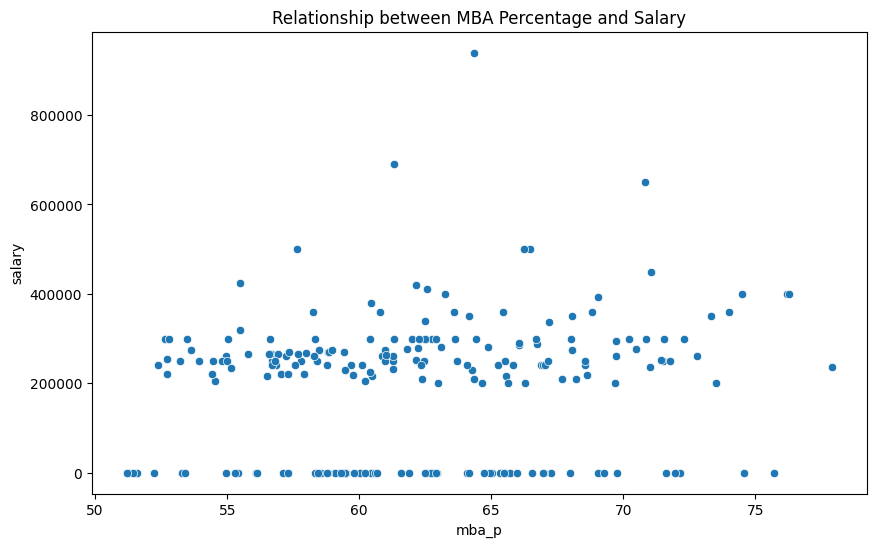

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='mba_p', y='salary', data=dataset)
plt.title('Relationship between MBA Percentage and Salary')
plt.show()

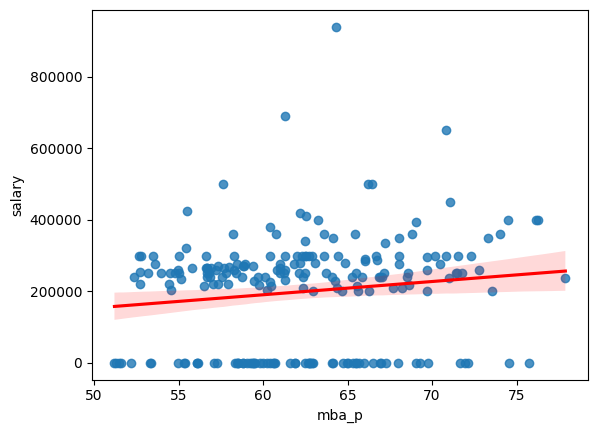

In [76]:
sns.regplot(x='mba_p', y='salary', data=dataset, line_kws={"color": "red"})
plt.show()

In [77]:
# placed_only = dataset.dropna(subset=['salary'])
# print(placed_only['mba_p'].corr(placed_only['salary']))

In [78]:
# Filter out both 0 and Null values
subset_df = dataset[(dataset['salary'] != 0) & (dataset['salary'].notnull())]

In [80]:
cor_rel = subset_df['mba_p'].corr(subset_df['salary'])
print(f"Correlation between MBA_P and Salary: {cor_rel}")

Correlation between MBA_P and Salary: 0.17501294069527482


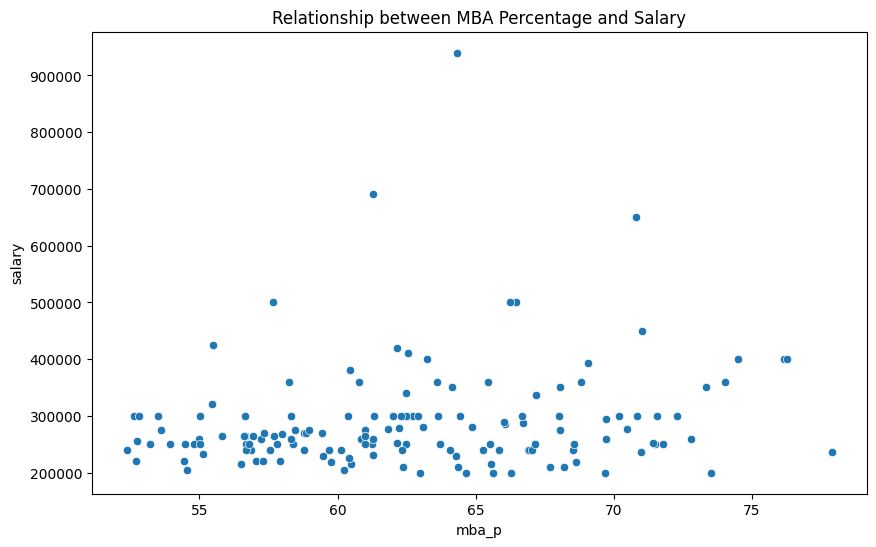

In [79]:
import matplotlib.pyplot as plt1
import seaborn as sns1

plt1.figure(figsize=(10, 6))
sns1.scatterplot(x='mba_p', y='salary', data=subset_df)
plt.title('Relationship between MBA Percentage and Salary')
plt.show()

In [81]:
## even after eliminating "Not Placed" ; Correlation was only 0.175 so significant improvement

### 1.5 End

### 1.6 5)Which specialization is getting minimum salary?
### 1.6 START

In [176]:
#-------------------------------------------
#--------------------------------------------
##  Trials
#-------------------------------------------
#--------------------------------------------
# Sorts by Salary (High to Low), then by MBA Score (High to Low)
# advanced_sort = placed_students.sort_values(by=['salary', 'mba_p'], ascending=[False, False])

# print(advanced_sort)

# distinct_specializations = placed_students['specialisation'].unique()
# print(distinct_specializations)

# # Returns only the 'salary' column for the 'Mkt&Fin' group
# mkt_fin_salaries = placed_students[placed_students['specialisation'] == 'Mkt&Fin']['salary']
# print(mkt_fin_salaries)

# # Syntax: .loc[row_condition, column_name]
# salaries = placed_students.loc[placed_students['specialisation'] == 'Mkt&HR', 'salary']
# print(salaries)

# # Group by specialization and find the minimum salary
# salary_by_spec = placed_students.groupby('specialisation')
# print(salary_by_spec)
# #min_salary_by_spec = placed_students.groupby('specialisation')['salary'].min()
# #print(min_salary_by_spec)

In [175]:
# Filter out 0 and Nulls first so we only look at placed students
placed_students = dataset[dataset['salary'] > 0]

# Group by specialization and find the minimum salary
min_salary_by_spec = placed_students.groupby('specialisation')['salary'].min()
print(min_salary_by_spec)
#-------------------------------------------
#--------------------------------------------


specialisation
Mkt&Fin    200000.0
Mkt&HR     200000.0
Name: salary, dtype: float64


### 1.6 Inference:
### min salary drawn is 200,000.00
### 1.6 END

### 1.7 6)How many of them getting above 500000 salary?
### 1.7 Start

In [111]:
# Filter out 0 and Nulls first so we only look at placed students
placed_students = dataset[dataset['salary'] > 500000]


In [112]:
placed_students

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
119,120,M,60.8,Central,68.40,Central,Commerce,64.6,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
150,151,M,71.0,Central,58.66,Central,Science,58.0,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0
177,178,F,73.0,Central,97.00,Others,Commerce,79.0,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0


In [172]:
print(f"Number of associates earning ab500,000.00 is : {placed_students.shape[0]}")

Number of associates earning ab500,000.00 is : 3


### Number of associates earning above 500,000.00 is : 3
### 1.7 End

### 1.8 7)Test the Analysis of Variance between etest_p and mba_p at signifance
### level 5%.(Make decision using Hypothesis Testing)
### 1.8 Start

In [120]:
from scipy import stats

# Ensure we drop any null values to avoid errors in calculation
etest = dataset['etest_p'].dropna()
mba = dataset['mba_p'].dropna()

# Perform One-Way ANOVA
f_statistic, p_value = stats.f_oneway(etest, mba)

print(f"F-Statistic: {f_statistic}")
print(f"P-Value: {p_value}")


#from scipy.stats import ttest_ind
#dataset=dataset.dropna()
#commerce = dataset[dataset['hsc_s']=='Commerce']['mba_p']
#science = dataset[dataset['hsc_s']=='Science']['mba_p']
##print(male)
#ttest_ind(etest,mba)

#Make the Decision
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H0)")
    print("Conclusion: There is a significant difference between etest_p and mba_p.")
else:
    print("Decision: Fail to Reject the Null Hypothesis (H0)")
    print("Conclusion: There is no significant difference between etest_p and mba_p.")

F-Statistic: 98.64487057324706
P-Value: 4.672547689133573e-21
Decision: Reject the Null Hypothesis (H0)
Conclusion: There is a significant difference between etest_p and mba_p.


## Decision: Reject the Null Hypothesis (H0)
## Conclusion: There is a significant difference between etest_p and mba_p.
## 1.8 END

### ---------------------------------------------------------
### 1.9 8)Test the similarity between the degree_t(Sci&Tech) 
###       and specialisation(Mkt&HR) with respect 
###       to salary at significance level of 5%.
###       (Make decision using Hypothesis Testing)
### 1.9 START

In [123]:
from scipy import stats

# Assuming 'df' is your dataframe
scitech_salary = dataset[dataset['degree_t'] == 'Sci&Tech']['salary']
mkt_hr_salary = dataset[dataset['specialisation'] == 'Mkt&HR']['salary']

# Perform Independent T-test
t_stat, p_value = stats.ttest_ind(scitech_salary, mkt_hr_salary, nan_policy='omit')

print(f"P-Value: {p_value}")

P-Value: 0.007897969943471179


In [ ]:
### 1. Comparison
P-Value: 0.007897
Alpha α : 0.05
Condition: 0.007897 < 0.05 ==> True

### 2. The Decision
### Reject the Null Hypothesis (H0).

### 3. Statistical Interpretation
### Because the p-value is less than the significance level, we conclude 
### that the difference in mean salaries between the **Sci&Tech** degree holders and **Mkt&HR** 
### specialisation holders is not due to random chance. 

### 4. Final Conclusion
### At a **5% significance level**, there is sufficient evidence to state 
### that the salaries for these two groups are **not similar**.
### There is a statistically significant difference in the salary levels associated 
### with the Sci&Tech degree and the Mkt&HR specialisation.

### 1.9 END
### --------------------

### 1.10 9)Convert the normal distribution to standard normal distribution for
### salary column
### 1.10 Start

In [173]:
##using pandas
# Calculating mean and standard deviation << (Xi- mean)/standard deviation >>
mean_salary = dataset['salary'].mean()
std_salary = dataset['salary'].std()

# Applying the formula
dataset['salary_zscore'] = (dataset['salary'] - mean_salary) / std_salary

In [127]:
dataset['salary_zscore']

0      0.460636
1      0.008384
2      0.331421
3     -1.283765
4      1.462051
         ...   
210    1.300533
211    0.492940
212    0.622155
213    0.034227
214   -1.283765
Name: salary_zscore, Length: 215, dtype: float64

In [133]:
from scipy import stats
dataset_scipy=pd.read_csv('Placement.csv')
dataset_scipy["salary"].fillna(0,inplace=True) # remove Nan

# This returns an array of z-scores
# stats.zscore(dataset_scipy['salary'], nan_policy='omit')
# 'propagate'	(Default) If there is even one NaN in our data, the entire result for that column becomes NaN.
# 'omit'	Skips the NaNs, calculates the score for the numbers, and leaves NaNs where they were.
#'raise'	Throws a ValueError immediately if a NaN is detected.
#           This is useful if you want to ensure your dataset is perfectly clean before processing.

dataset_scipy['salary_zscore'] = stats.zscore(dataset_scipy['salary'], nan_policy='omit')



In [131]:
dataset_scipy['salary_zscore']

0      0.461711
1      0.008404
2      0.332195
3     -1.286761
4      1.465463
         ...   
210    1.303568
211    0.494090
212    0.623607
213    0.034307
214   -1.286761
Name: salary_zscore, Length: 215, dtype: float64

### 1.10 End
### ----------------------------------------------

### 1.11 10)What is the probability Density Function of the salary range from
### 700000 to 900000?

### 1.11 Start

In [143]:
### PDF is the mathematical tool that describes the likelihood of a continuous random variable (like salary) 
### falling within a particular range.

### 1. The Statistical Definition (Probability Density Function)
### Unlike a discrete variable (where you can count outcomes, like rolling a die), 
### continuous variables like salary can take any value. 
### The PDF represents the "density" of probability at any given point.

### The Area is Key: The value of the PDF at a specific point isn't the probability itself. 
### Instead, the area under the curve between two points represents the probability that a value falls in that range.
### Total Area = 1: The total area under the entire PDF curve must equal 1 (or 100%), representing all possible outcomes.

### When we calculate a Z-score, you are essentially transforming the data into a Standard Normal Distribution, 
### where the PDF is centered at 0 with a standard deviation of 1.

In [142]:
mean_s = mean_salary
std_s = std_salary
print (f"mean:{mean_s}\n Std:{std_s}")

mean:198702.32558139536
 Std:154780.92671560097


In [170]:
from scipy.stats import norm

### some of the functions/methods present in norm
### The `scipy.stats.norm` module represents the **Gaussian (Normal) continuous random variable**.
### It is packed with methods that allow you to perform almost any statistical operation
### from finding probabilities to generating random data.

### Probability Calculations
### These methods help us find the area under the curve (probabilities).

### pdf(x) (Probability Density Function): Returns the height of the curve at point x. 
### It’s useful for drawing the Bell Curve, but not for finding "chance" 
### (since the probability at a single point in a continuous distribution is zero).

### cdf(x) (Cumulative Distribution Function): Returns the probability that a value is less than or equal to x. 
### This is the "Area to the left."

### sf(x) (Survival Function): Returns the probability that a value is greater than $x$. This is 1 - cdf. 
### It is the "Area to the right."


# Parameters used in the previous step
mean_s = mean_salary
std_s = std_salary

# Calculating the probability for the range [700,000, 900,000]
# This is Area under the curve = CDF(upper) - CDF(lower)
prob = norm.cdf(900000, loc=mean_s, scale=std_s) - norm.cdf(700000, loc=mean_s, scale=std_s)

# Calculating PDF values at the points
pdf_700k = norm.pdf(700000, loc=mean_s, scale=std_s)
pdf_900k = norm.pdf(900000, loc=mean_s, scale=std_s)

print(f"Probability: {prob}")
print(f"PDF at 700,000: {pdf_700k}")
print(f"PDF at 900,000: {pdf_900k}")


Probability: 0.0005973243061798694
PDF at 700,000: 1.3596204396845918e-08
PDF at 900,000: 8.98163035735494e-11


### 1.11 End

### -----------------------
### 1.12 11)Test the similarity between the degree_t(Sci&Tech)with respect to
### etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)
### 1.12 Start

In [ ]:
## To test whether the performance of Sci&Tech students in the entrance test (etest_p)
## is similar to their performance in the MBA program (mba_p), we should use  a Paired Samples T-test.
## This test is appropriate because we are comparing two different scores (Entrance Test vs. MBA) 
## for the same group of people (the Sci&Tech students).

## What we are going to address
## -------------------------------
## 1.Null Hypothesis (H0): which implies there is no significant difference 
## between the mean scores of etest_p and mba_p for Sci&Tech students (µ_{etest} = µ_{mba}$).

## Alternative Hypothesis (H_α): There is a significant difference between the mean scores of etest_p and mba_p 
## for Sci&Tech students 
## (µ_{etest} != \µ_{mba}).

## 2. Set the Significance LevelAlpha (α): 0.05 (5%)

In [150]:
from scipy import stats

# 1. Filter the data for Sci&Tech students
scitech_data = dataset[dataset['degree_t'] == 'Sci&Tech']

# 2. Perform Paired T-test
# we use ttest_rel because the two scores are related to the same students
t_stat, p_value = stats.ttest_rel(scitech_data['etest_p'], scitech_data['mba_p'])

print(f"P-Value: {p_value} \n t_stat : {t_stat}")

P-Value: 5.517920600505392e-06 
 t_stat : 5.0049844583693615


In [151]:
### Based on the results, the analysis as follows

### 1. The Comparison
###-------------
### Significance Level (α):0.05
### P-Value: 0.000005517 (Scientific notation: 5.51 * 10 power-6
### T-Statistic: 5.0049
### Since the p-value (0.0000055) is significantly smaller than α (0.05)reject the null hypothesis.

### conclusion
###------------------------
### Since p < 0.05, we reject the null hypothesis. 
### We conclude that for Sci&Tech students,
### there is a significant shift in performance between their entrance exams and their MBA program scores; 
### both do not perform at a "similar" level

In [149]:
###--------------------------
###---------------------------
### Extra information below
###----------------------------
###-----------------

In [174]:
    
### Why do we use Paired T-test instead of ANOVA
### ---------------------------------------------
### While ANOVA is used to compare different groups (like Sci&Tech vs. Commerce), 
### a Paired T-test (or Dependent T-test) is much more powerful when you are looking at the same group of people across 
### two different metrics. It accounts for the fact that a student who is naturally good at exams might score high in both, 
### focusing instead on the difference between their two scores.

### 1.12 End
### -------------------------------------

### 1.13 12)Which parameter is highly correlated with salary?
### ---------------------------------------------
### 1.13 start

In [152]:
dataset[quan].corr()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.078155,-0.085711,-0.088281,0.063636,0.022327,0.002543
ssc_p,-0.078155,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,-0.085711,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,-0.088281,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.063636,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.022327,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.002543,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


In [ ]:
#Based on the correlation matrix provided, the parameter highly correlated with **salary** is:

### ssc_p (10th Grade Percentage)
# Correlation Value: 0.538090
### Breakdown of Correlations with Salary:
1.  **ssc_p:** 0.538090 (Highest)
2.  **hsc_p:** 0.452569
3.  **degree_p:** 0.408371
4.  **etest_p:** 0.186988
5.  **mba_p:** 0.139823

### **What does this mean?**
# A correlation of **0.538** indicates a **moderate positive relationship**. 
# This suggests that among the variables listed, a student's performance in their 10th-grade exams (ssc_p) 
# is the strongest statistical predictor of their starting salary in this dataset. 
# As the ssc_p score increases, there is a general tendency for the $salary$ to increase as well.

### Summary of Strength:**
Strong Correlation:** 0.7 to 1.0
Moderate Correlation:** 0.3 to 0.7 (Where ssc_p, hsc_p, and degree_p ==> values are in this range)
Weak Correlation:** 0.0 to 0.3 (Where etest_p and mba_p ==> values are in this range)


### 1.13 End

### 1.14 13) plot any useful graph and explain it.
### ----------------------------------------------
### 1.14 Start

### plotting Standard Normal Distribution (Z-scores) of ssc_p

In [167]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((j-mean)/std) for j in values]

    #sns.distplot(z_score,kde=True)
    sns.histplot(z_score, kde=True, stat="density", color='skyblue')
    plt.title("Standard Normal Distribution (Z-scores) of ssc_p")
    plt.xlabel("Z-score (Standard Deviations from Mean)")
    plt.ylabel("Density")
    plt.axvline(0, color='red', linestyle='--') # Mark the mean
    plt.savefig("standardized_plot.png")
    return sum(z_score)/len(z_score)
    #z_score.std()
    

Mean of Z-scores: -4.2911410858767677e-16


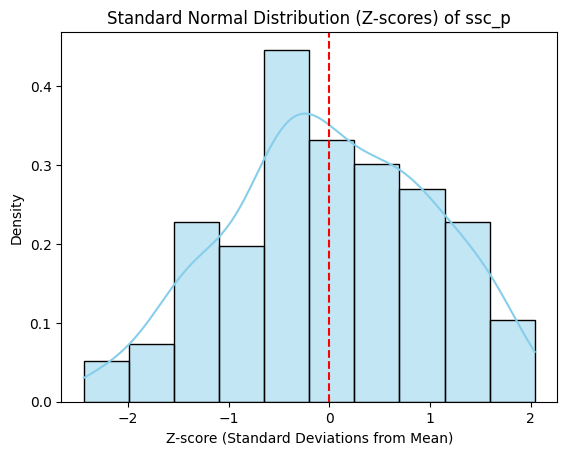

In [168]:

mean_of_z = stdNBgraph(dataset['ssc_p'])
print(f"Mean of Z-scores: {mean_of_z}")

### 1.14 END

### END of Assignment